# RL1 - Notebook 1 - Markov Decision Processes

In this notebook, you will build on your experience with creating Markov Decision Process (MDP) objects in the first notebook. You will use the MDPs to create a simulation object that can simulate the interaction between an agent and an MDP. You will also explore how a simulation creates a **trace** or **history**, a record of the agent-environment interaction, and how to evaluate the **return** of a trace.

In order to run this, and subsequent notebooks you will need to clone the github repository located [here](https://github.com/lukedickens/inst0075-code).

When cloned to a suitable location of your machine open a terminal and change directory to the top level directory of the cloned project then run the following pip command.

`pip install -e .`

This will allow you to access this code library from other locations.

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from inst0075.rl.environment.model.mdp import MDP
from inst0075.rl.environment.states_and_actions import get_unbiased_policy
from inst0075.rl.visualisation import (
    plot_mdp_matrices,
    report_mdp_summary
)
import inst0075.rl.environment.model.example_mdps as example_mdps

ModuleNotFoundError: No module named 'inst0075.rl.environment.model.visualisation'

## Stair climbing MDP

![title](img/stair_climbing_mdp.png)


The image shows the stair climbing Markov Decision Process (MDP) from the lecture notes. There are 7 states and two actions L(eft) and R(ight) taking you up and down the stairs respectively. Except for when moving to absorbing states P or G, then moving left gives reward 1 and moving right gives reward -1 (its harder going up than down stairs). Moving to the goal, state G, gives a reward of 10 and terminates the episode. Moving to the bottom of the stair, state P, gives negative reward of -10 and also terminates the episode (the agent has failed to climb the stairs).


The code blocks below creates a python `MDP` object representing this MDP. It outputs the properties of the model and shows the transition probabilities (stored in tensor T) and the reward function (stored in tensor R). Look at the output and relate this to your knowledge of the model.


In [4]:
# Create the stair-climbing MDP from the lecture videos
stair_mdp = example_mdps.stair_climbing_mdp()


stair_mdp_summary = report_mdp_summary(stair_mdp)
display(stair_mdp_summary)

,Property,Value
0,States,7
1,Actions,2
2,State Names,"P, s1, s2, s3, s4, s5, G"
3,Action Names,"L, R"
4,Initial State Distribution,"[False, False, False, True, False, False, False]"


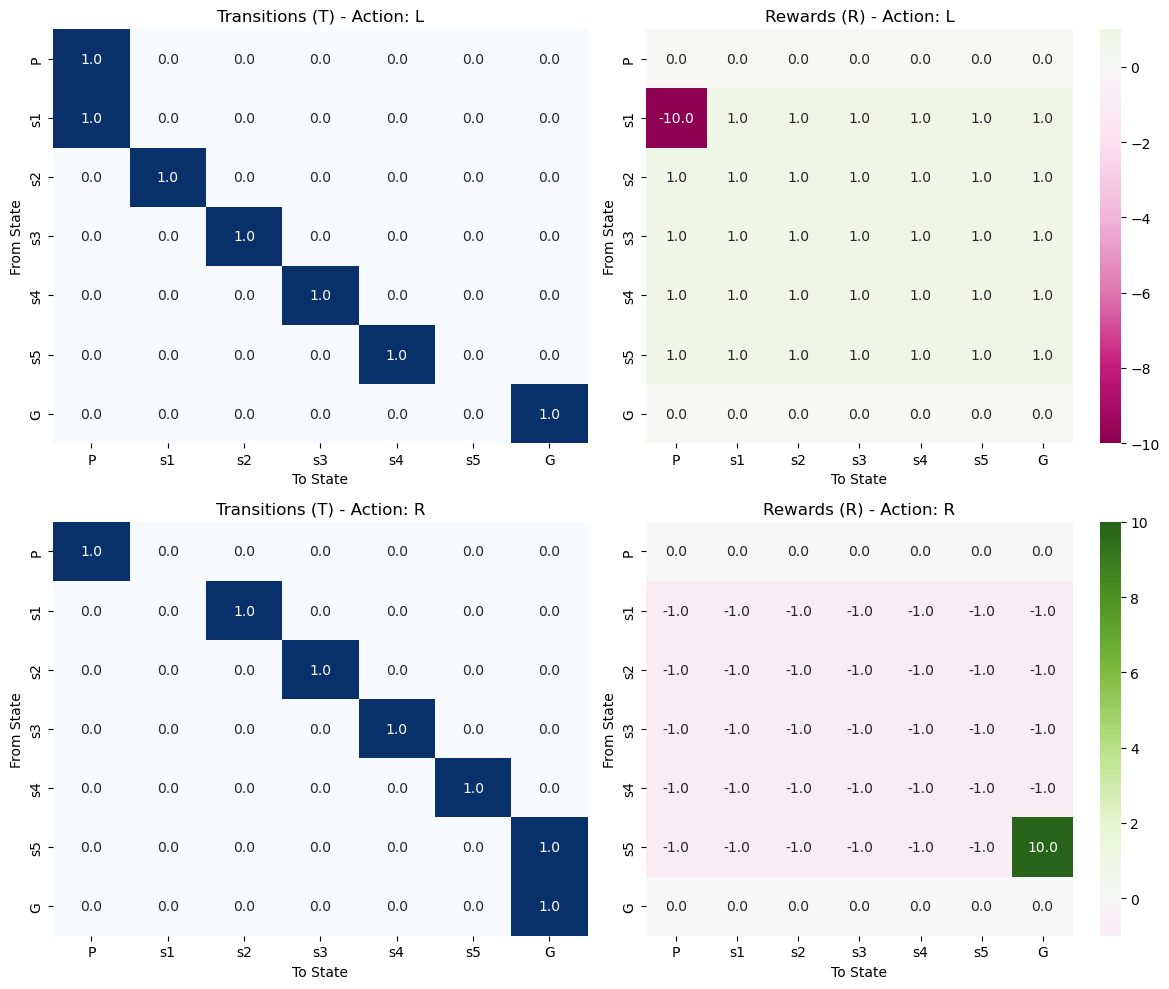

In [5]:
# Visualise the transition matrix/function and reward function
plot_mdp_matrices(stair_mdp)

## Defining the Stop-Go MDP

Consider an MDP with the following properties:
* two states, $\{1,2\}$
* two actions $\{\text{stop}, \text{go}\}$
* no absorbing states
* and initial distribution
$$p(s_0 = 1) = p(s_0 = 2) = \frac{1}{2}$$
* transition function:
$$
t(s,a,s') = 
\begin{cases}
1 & \text{if } a = \text{stop}, \text{ and } s = s' \\
1 & \text{if } a = \text{go}, \text{ and } s \neq s' \\
0 & \text{otherwise}
\end{cases}
$$
* reward function:
$$r(s,a,s') = 
\begin{cases}
1 & \text{if } a = \text{stop}, \text{ and } s = 1 \\
2 & \text{if } a = \text{go}, \text{ and } s = 2 \\
0 & \text{otherwise}
\end{cases}$$

Draw this MDP with a pencil and paper.


In [6]:
def build_stop_go_mdp():
    """
      Creates a model of the stop-go MDP from the tutorial
    """
    # TODO: Comple
    state_names =  None 
    action_names =  None
    absorbing = None
    initial = None

    # TODO: Define the transition function
    def stop_go_t_func(s, a, s_):
        return 0.0

    # TODO: Define the reward function
    def stop_go_r_func(s, a, s_):
        return 0

    mdp = MDP(
        state_names, action_names, initial, absorbing,
        t_function=stop_go_t_func, r_function=stop_go_r_func)

    return mdp

In [7]:
# Create stop-go MDP
stop_go_mdp = example_mdps.stop_go_mdp()
# Construct and display MDP summary.
stop_go_mdp_summary = report_mdp_summary(stop_go_mdp)
display(stop_go_mdp_summary)

,Property,Value
0,States,2
1,Actions,2
2,State Names,"1, 2"
3,Action Names,"stop, go"
4,Initial State Distribution,"[1, 1]"


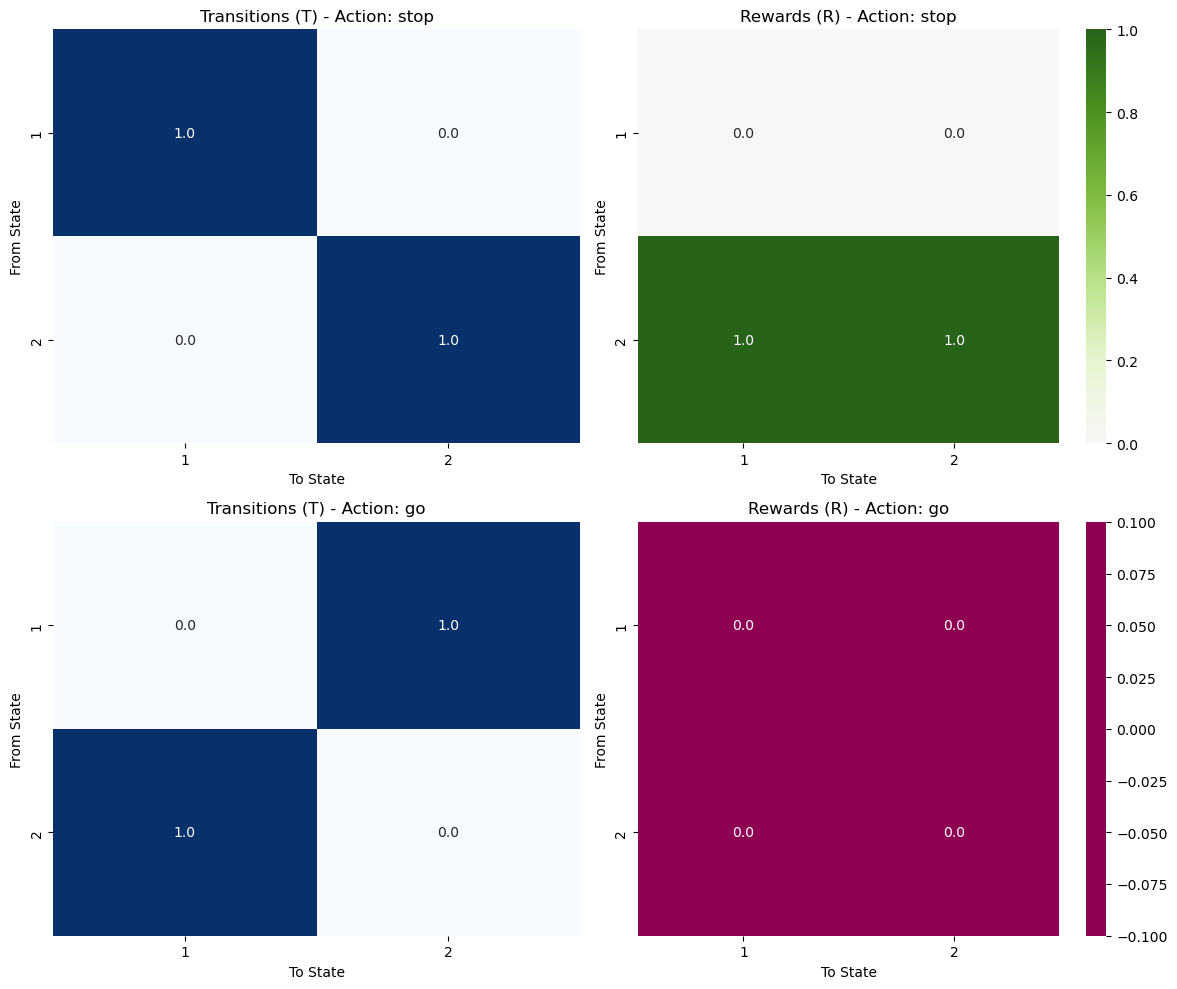

In [8]:
# Visualise the transition matrix/function and reward function
plot_mdp_matrices(stop_go_mdp)